<a href="https://colab.research.google.com/github/Tolugold2704/knowledge_check_module1/blob/main/Usan_Reservoir_Temperature_Calculator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reservoir Temperature Calculator

This function estimates reservoir temperature using reservoir depth, surface temperature, and geothermal gradient.

## Formula

```text
Reservoir Temperature = Surface Temperature + (Geothermal Gradient × Depth in m)

In [ ]:
def reservoir_temperature (
    depth_m:float,
    surface_temp:float=4.0,
    gradient:float=30.0
):
    """ Calculating reservoir temperature
    Parameters:
    depth_m: depth of the well in metres
    surface_temp: surface temperature at a particular depth
    gradient: slope
    Return:
    Estimated values
    """
    if depth <0:
        raise ValueError(f"depth cant be negative:{depth_m}")
    return surface_temp + (gradient * depth_m / 100)
for depth in [34,56,34, 23]:
    temp = reservoir_temperature(depth)
    print(f"DEPTH:{temp} C")

# Well Temperature Calculator

This program reads well-depth data from a CSV file and calculates the estimated temperature for each well.

## Requirements

Install Pandas:

```bash
pip install pandas

In [19]:
import pandas as pd
df = pd.read_csv("/content/well_depths.csv")
df
def calculate_temperature(depth_m,Surface_temp = 12,gradient =0.25):
    return Surface_temp + (gradient * depth_m)
    #Apply the functions to all wells
df['Temperature_C'] = df['depth_m']. apply(calculate_temperature)
print(df)


     well_id  depth_m  Temperature_C
0   WELL_001  1623.62       417.9050
1   WELL_002  3352.14       850.0350
2   WELL_003  2695.98       685.9950
3   WELL_004  2295.98       585.9950
4   WELL_005   968.06       254.0150
5   WELL_006   967.98       253.9950
6   WELL_007   674.25       180.5625
7   WELL_008  3098.53       786.6325
8   WELL_009  2303.35       587.8375
9   WELL_010  2624.22       668.0550
10  WELL_011   561.75       152.4375
11  WELL_012  3409.73       864.4325
12  WELL_013  2997.33       761.3325
13  WELL_014  1137.02       296.2550
14  WELL_015  1045.47       273.3675
15  WELL_016  1050.21       274.5525
16  WELL_017  1412.73       365.1825
17  WELL_018  2074.27       530.5675
18  WELL_019  1795.84       460.9600
19  WELL_020  1373.69       355.4225
20  WELL_021  2335.56       595.8900
21  WELL_022   918.48       241.6200
22  WELL_023  1376.43       356.1075
23  WELL_024  1599.09       411.7725
24  WELL_025  1868.21       479.0525
25  WELL_026  2855.53       725.8825
2

## Purpose

The program:

- Stores depth and temperature data
- Checks that both datasets have the same number of values
- Calculates a linear regression trendline
- Displays the data points and trendline on a chart
- Labels the chart with appropriate units

## Requirements

Install the required Python libraries:

```bash
pip install numpy matplotlib

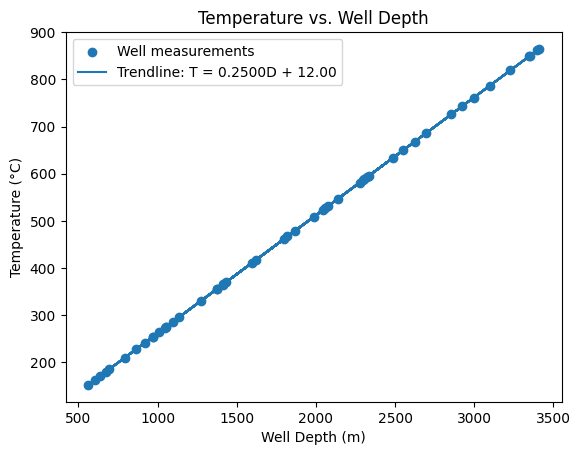

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Get depth and temperature data
depth = df["depth_m"]
temperature = df["Temperature_C"] # Corrected column name

# Calculate linear trendline
slope, intercept = np.polyfit(depth, temperature, 1)

# Calculate trendline values
trendline = slope * depth + intercept

# Create scatter plot
plt.scatter(depth, temperature, label="Well measurements")

# Add linear trendline
plt.plot(
    depth,
    trendline,
    label=f"Trendline: T = {slope:.4f}D + {intercept:.2f}"
)

# Add labels and title
plt.xlabel("Well Depth (m)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature vs. Well Depth")

# Add legend
plt.legend()

# Display the plot
plt.show()

# Reservoir Temperature Calculator with Error Handling

This program calculates estimated reservoir temperature using well depth, surface temperature, and geothermal gradient.

It also checks for invalid inputs, such as negative depth or text entered where a number is required.

## Formula

```text
Reservoir Temperature = Surface Temperature + (Gradient × Depth / 100)

In [22]:
def reservoir_temperature(
    depth_m: float,
    surface_temp: float = 4.0,
    gradient: float = 30.0
) -> float:
    """
    Calculates the estimated reservoir temperature at a given depth.

    Parameters:
    depth_m (float): Depth of the well in meters. Must be a non-negative numeric value.
    surface_temp (float): Surface temperature in Celsius. Must be a numeric value.
    gradient (float): Geothermal gradient in Celsius per 100 meters. Must be a numeric value.

    Returns:
    float: Estimated reservoir temperature in Celsius.

    Raises:
    TypeError: If depth_m, surface_temp, or gradient are not numeric.
    ValueError: If depth_m is negative.
    """
    # Validate depth_m type
    if not isinstance(depth_m, (int, float)):
        raise TypeError(f"Depth must be a numeric value, got {type(depth_m).__name__}.")

    # Validate depth_m value
    if depth_m < 0:
        raise ValueError(f"Depth cannot be negative: {depth_m} meters.")

    # Validate surface_temp type
    if not isinstance(surface_temp, (int, float)):
        raise TypeError(f"Surface temperature must be a numeric value, got {type(surface_temp).__name__}.")

    # Validate gradient type
    if not isinstance(gradient, (int, float)):
        raise TypeError(f"Gradient must be a numeric value, got {type(gradient).__name__}.")

    # Calculate temperature (assuming gradient is in C per 100m)
    return surface_temp + (gradient * depth_m / 100)

# Test Cases

print("--- Running Test Cases ---")

# Test Case 1: Valid input (using default surface_temp and gradient)
try:
    temp1 = reservoir_temperature(1000)
    print(f"Test Case 1 (Valid Input, defaults): Depth=1000m -> Expected: 304.0C, Got: {temp1:.1f}C")
    assert abs(temp1 - 304.0) < 0.001, "Test Case 1 Failed"
except (TypeError, ValueError) as e:
    print(f"Test Case 1 Failed unexpectedly: {e}")

# Test Case 2: Valid input (custom values)
try:
    temp2 = reservoir_temperature(500, surface_temp=15.0, gradient=2.0)
    print(f"Test Case 2 (Valid Input, custom): Depth=500m, Surface=15C, Gradient=2C/100m -> Expected: 25.0C, Got: {temp2:.1f}C")
    assert abs(temp2 - 25.0) < 0.001, "Test Case 2 Failed"
except (TypeError, ValueError) as e:
    print(f"Test Case 2 Failed unexpectedly: {e}")

# Test Case 3: Negative depth (invalid value)
try:
    temp3 = reservoir_temperature(-100)
    print(f"Test Case 3 (Negative Depth): Expected: ValueError")
except ValueError as e:
    print(f"Test Case 3 (Negative Depth): Caught expected error: {e}")
except Exception as e:
    print(f"Test Case 3 (Negative Depth): Caught unexpected error type: {type(e).__name__}: {e} (FAILED)")

# Test Case 4: Non-numeric depth (invalid type)
try:
    temp4 = reservoir_temperature("two hundred")
    print(f"Test Case 4 (Non-numeric Depth): Expected: TypeError")
except TypeError as e:
    print(f"Test Case 4 (Non-numeric Depth): Caught expected error: {e}")
except Exception as e:
    print(f"Test Case 4 (Non-numeric Depth): Caught unexpected error type: {type(e).__name__}: {e} (FAILED)")

# Test Case 5: Non-numeric surface_temp (invalid type)
try:
    temp5 = reservoir_temperature(100, surface_temp="abc")
    print(f"Test Case 5 (Non-numeric Surface Temp): Expected: TypeError")
except TypeError as e:
    print(f"Test Case 5 (Non-numeric Surface Temp): Caught expected error: {e}")
except Exception as e:
    print(f"Test Case 5 (Non-numeric Surface Temp): Caught unexpected error type: {type(e).__name__}: {e} (FAILED)")

# Test Case 6: Zero depth (valid input)
try:
    temp6 = reservoir_temperature(0, surface_temp=5, gradient=3)
    print(f"Test Case 6 (Zero Depth): Expected: 5.0C, Got: {temp6:.1f}C")
    assert abs(temp6 - 5.0) < 0.001, "Test Case 6 Failed"
except (TypeError, ValueError) as e:
    print(f"Test Case 6 Failed unexpectedly: {e}")

print("--- Test Cases Finished ---")

--- Running Test Cases ---
Test Case 1 (Valid Input, defaults): Depth=1000m -> Expected: 304.0C, Got: 304.0C
Test Case 2 (Valid Input, custom): Depth=500m, Surface=15C, Gradient=2C/100m -> Expected: 25.0C, Got: 25.0C
Test Case 3 (Negative Depth): Caught expected error: Depth cannot be negative: -100 meters.
Test Case 4 (Non-numeric Depth): Caught expected error: Depth must be a numeric value, got str.
Test Case 5 (Non-numeric Surface Temp): Caught expected error: Surface temperature must be a numeric value, got str.
Test Case 6 (Zero Depth): Expected: 5.0C, Got: 5.0C
--- Test Cases Finished ---
